Hazır. Veri boyutu: (2000, 7)


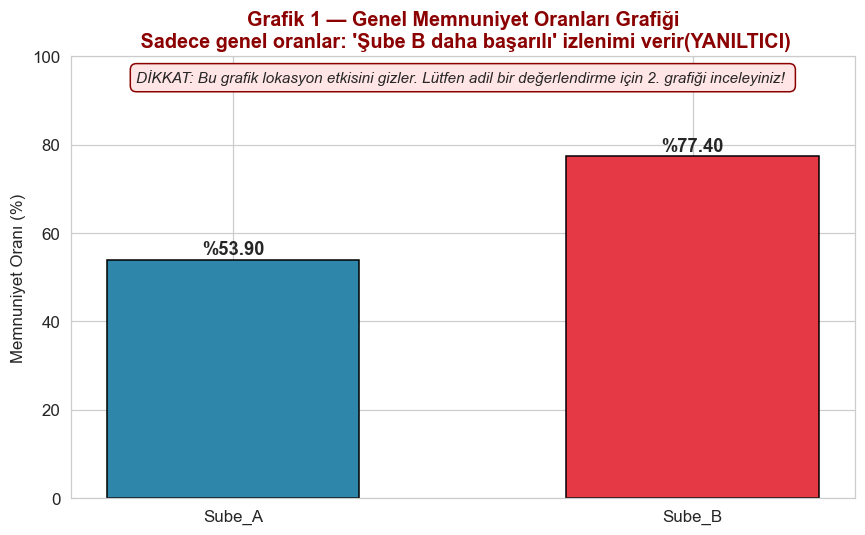

In [20]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Stil ayarları — tüm grafikler tutarlı görünsün
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

# Sabit renk paleti — şube kimlikleri her grafikte aynı renkte olsun
SUBE_COLORS = {"Sube_A": "#2E86AB", "Sube_B": "#E63946"}
LOC_COLORS  = {"avm": "#F4A261", "sanayi": "#264653"}

# Veri
df = pd.read_csv("../01-data/restaurant_branch_success.csv")
df["memnun_bool"] = (df["musteri_memnun"] == "evet").astype(int)

# Çıktı klasörü
os.makedirs("figures", exist_ok=True)

print("Hazır. Veri boyutu:", df.shape)


fig, ax = plt.subplots(figsize=(8, 5))

genel = df.groupby("model")["memnun_bool"].mean() * 100
colors = [SUBE_COLORS[s] for s in genel.index]

bars = ax.bar(genel.index, genel.values, color=colors, edgecolor="black", width=0.55)

# Her çubuğun üstüne değeri yaz
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.2,
            f"%{bar.get_height():.2f}", ha="center", fontweight="bold", fontsize=12)

ax.set_ylabel("Memnuniyet Oranı (%)")
ax.set_ylim(0, 100)
ax.set_title("Grafik 1 — Genel Memnuniyet Oranları Grafiği\n "
             "Sadece genel oranlar: 'Şube B daha başarılı' izlenimi verir(YANILTICI)",
             color="#8B0000")

# Uyarı kutusu
ax.text(0.5, 0.97,
        "DİKKAT: Bu grafik lokasyon etkisini gizler. Lütfen adil bir değerlendirme için 2. grafiği inceleyiniz! ",
        transform=ax.transAxes, ha="center", va="top",
        fontsize=10, style="italic",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#FFE5E5", edgecolor="#8B0000"))

plt.tight_layout()
plt.savefig("figures/grafik1_naif.png", dpi=150, bbox_inches="tight")
plt.show()


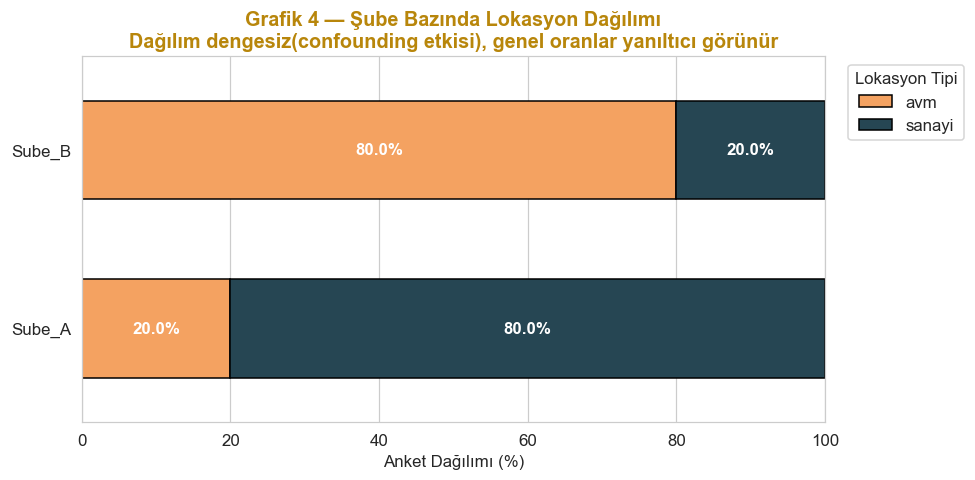

In [26]:
fig, ax = plt.subplots(figsize=(9, 4.5))

dagilim = pd.crosstab(df["model"], df["lokasyon_tipi"], normalize="index") * 100
dagilim = dagilim[["avm", "sanayi"]]  # sıra sabit

dagilim.plot(
    kind="barh", stacked=True, ax=ax,
    color=[LOC_COLORS["avm"], LOC_COLORS["sanayi"]],
    edgecolor="black", width=0.55,
)

# Her segmentin ortasına yüzdeyi yaz
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center",
                 color="white", fontweight="bold", fontsize=11)

ax.set_xlabel("Anket Dağılımı (%)")
ax.set_ylabel("")
ax.set_xlim(0, 100)
ax.set_title("Grafik 4 — Şube Bazında Lokasyon Dağılımı\n"
             "Dağılım dengesiz(confounding etkisi), genel oranlar yanıltıcı görünür",
             color="#B8860B");
ax.legend(title="Lokasyon Tipi", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig("figures/grafik2_dagilim.png", dpi=150, bbox_inches="tight")
plt.show()

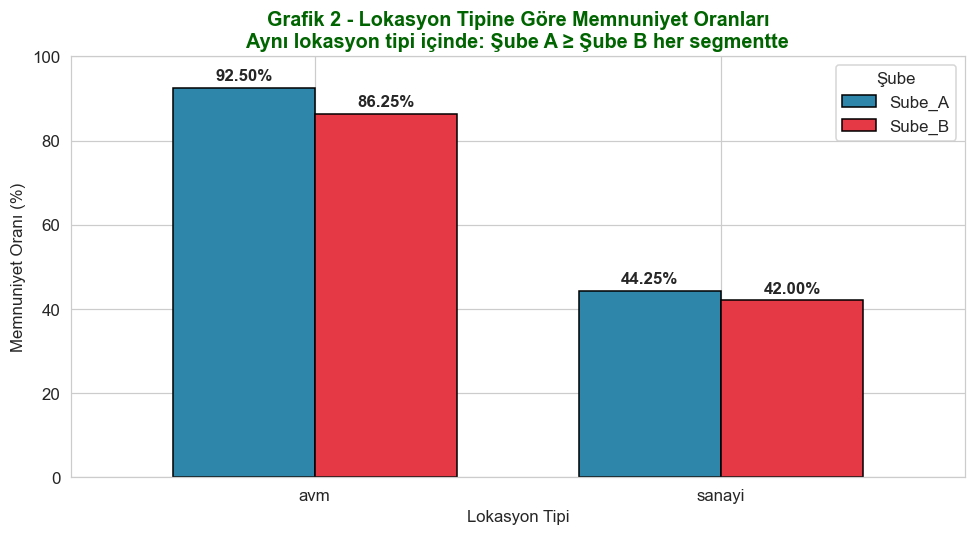

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))

strat = (df.groupby(["lokasyon_tipi", "model"])["memnun_bool"]
           .mean().unstack() * 100)[["Sube_A", "Sube_B"]]

strat.plot(
    kind="bar", ax=ax,
    color=[SUBE_COLORS["Sube_A"], SUBE_COLORS["Sube_B"]],
    edgecolor="black", width=0.7,
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3, fontweight="bold", fontsize=11)

ax.set_xlabel("Lokasyon Tipi")
ax.set_ylabel("Memnuniyet Oranı (%)")
ax.set_ylim(0, 100)
ax.set_title("Grafik 2 - Lokasyon Tipine Göre Memnuniyet Oranları\n"
             "Aynı lokasyon tipi içinde: Şube A ≥ Şube B her segmentte",
             color="#006400")
ax.legend(title="Şube")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("figures/grafik3_stratifiye.png", dpi=150, bbox_inches="tight")
plt.show()

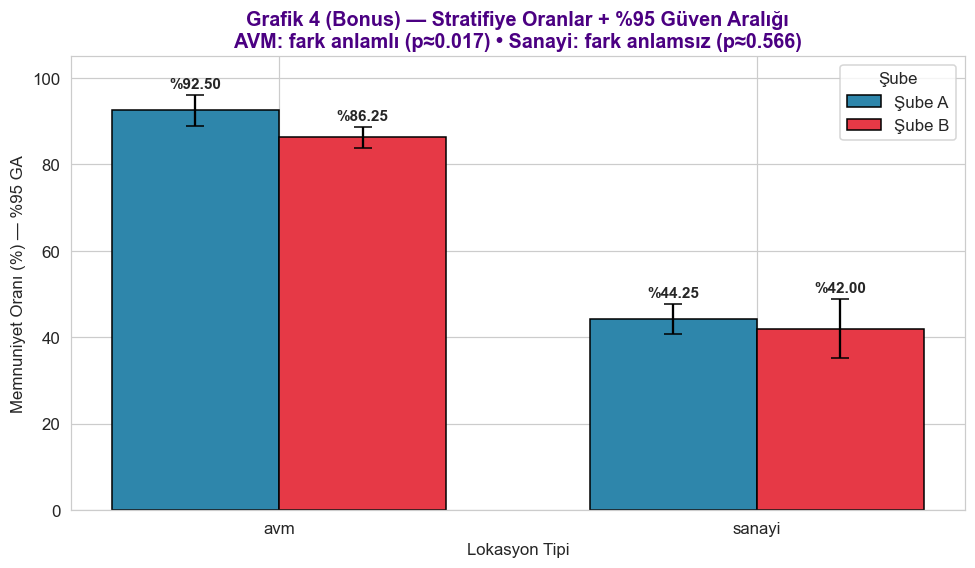

In [23]:
# Standart hata: sqrt(p*(1-p)/n), %95 CI: 1.96 * SE
agg = df.groupby(["lokasyon_tipi", "model"]).agg(
    p=("memnun_bool", "mean"),
    n=("memnun_bool", "count"),
)
agg["se"]  = np.sqrt(agg["p"] * (1 - agg["p"]) / agg["n"])
agg["ci"]  = 1.96 * agg["se"] * 100
agg["p100"] = agg["p"] * 100

p_mat  = agg["p100"].unstack()[["Sube_A", "Sube_B"]]
ci_mat = agg["ci"].unstack()[["Sube_A", "Sube_B"]]

fig, ax = plt.subplots(figsize=(9, 5.3))
x = np.arange(len(p_mat.index))
w = 0.35

ax.bar(x - w/2, p_mat["Sube_A"], w, yerr=ci_mat["Sube_A"],
       label="Şube A", color=SUBE_COLORS["Sube_A"], edgecolor="black",
       capsize=6, error_kw={"elinewidth": 1.5})
ax.bar(x + w/2, p_mat["Sube_B"], w, yerr=ci_mat["Sube_B"],
       label="Şube B", color=SUBE_COLORS["Sube_B"], edgecolor="black",
       capsize=6, error_kw={"elinewidth": 1.5})

# Değerleri bar üstüne yaz
for i, loc in enumerate(p_mat.index):
    for j, sube in enumerate(["Sube_A", "Sube_B"]):
        val = p_mat.loc[loc, sube]
        offset = ci_mat.loc[loc, sube] + 1.5
        xpos = x[i] + (-w/2 if j == 0 else w/2)
        ax.text(xpos, val + offset, f"%{val:.2f}",
                ha="center", fontweight="bold", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(p_mat.index)
ax.set_ylabel("Memnuniyet Oranı (%) — %95 GA")
ax.set_xlabel("Lokasyon Tipi")
ax.set_ylim(0, 105)
ax.set_title("Grafik 4 (Bonus) — Stratifiye Oranlar + %95 Güven Aralığı\n"
             "AVM: fark anlamlı (p≈0.017) • Sanayi: fark anlamsız (p≈0.566)",
             color="#4B0082")
ax.legend(title="Şube")

plt.tight_layout()
plt.savefig("figures/grafik4_ci.png", dpi=150, bbox_inches="tight")
plt.show()

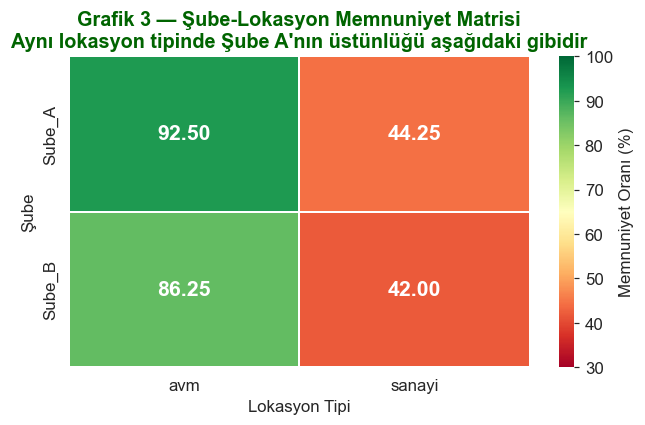

In [25]:
fig, ax = plt.subplots(figsize=(6, 4))

pivot = (df.groupby(["model", "lokasyon_tipi"])["memnun_bool"]
           .mean().unstack() * 100)[["avm", "sanayi"]]

sns.heatmap(
    pivot, annot=True, fmt=".2f", cmap="RdYlGn",
    vmin=30, vmax=100, linewidths=1, linecolor="white",
    cbar_kws={"label": "Memnuniyet Oranı (%)"},
    annot_kws={"fontsize": 14, "fontweight": "bold"}, ax=ax,
)

ax.set_xlabel("Lokasyon Tipi")
ax.set_ylabel("Şube")
ax.set_title("Grafik 3 — Şube-Lokasyon Memnuniyet Matrisi\n"
             "Aynı lokasyon tipinde Şube A'nın üstünlüğü aşağıdaki gibidir",
             color="#006400")

plt.tight_layout()
plt.savefig("figures/grafik5_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()